# Worksheet-3 Solution
## Modeling the Neuron: From MCP to Perceptron, Its Learning Algorithm, and Limitations

**Module:** Artificial Intelligence and Machine Learning  
**Institution:** Herald College Kathmandu  
**Submitted Date:** March 22, 2026

---

### Student Details

| Name | ID Number | Group |
| :--- | :--- | :--- |
| **Narayan Lohani** | 2408869 | L6CG15 |

---

<div style="display: flex; justify-content: space-between; align-items: center; border: none;">
  <img src="https://heraldcollege.edu.np/images/footer/footer-logo-dark.svg" width="180" alt="Herald College Logo">
  <img src="
  https://bizzeducation.com/storage/university-partners/May2024/r3iG0n8CHfh1nCAIz5BO.png" width="180" alt="University of Wolverhampton Logo">
</div>


# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This functions implements basic AND operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1 nd array): An array of binary values.
    X2 (1 nd array): An array of binary values.
    Output:
    state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
    """
    assert len(X1) == len(X2)
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let's name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    state_neuron = []
    for x1, x2 in zip(X1, X2):
        ele_sum = x1 + x2
        if ele_sum >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let's name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.

    state_neuron = []
    for x1, x2 in zip(X1, X2):
        ele_sum = x1 + x2
        if ele_sum >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Question 1: What does the shape of X represent?

The shape of `X` is `(12665, 784)`. The first dimension, **12665**, is the total number of images (samples/rows) in the dataset. The second dimension, **784**, corresponds to the number of pixel features per image (columns), since each MNIST image is 28 × 28 pixels, and 28 × 28 = 784. So each row of `X` is a flattened representation of one handwritten digit image.

### Question 2: What does the shape of y represent?

The shape of `y` is `(12665,)` — a one-dimensional array with one label per image. Each element is either `0` or `1`, indicating the digit class that the corresponding image in `X` belongs to. This vector is what the perceptron will learn to predict.

### Viewing the Dataset.

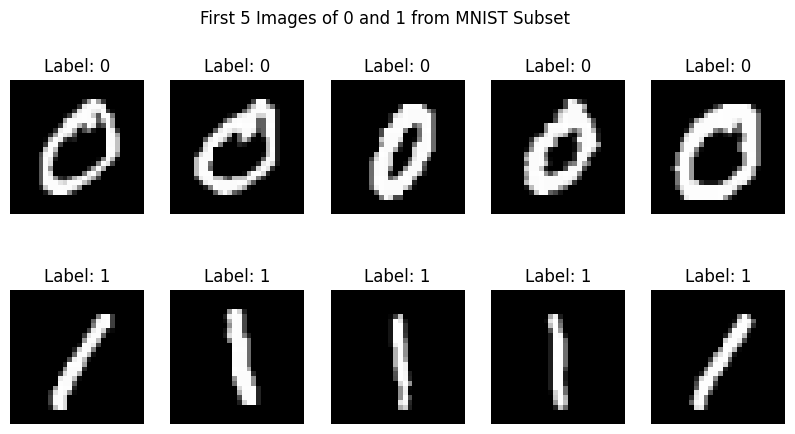

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()


## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

print(weights.shape)


(784,)


### Question 3: What does the weights array represent in this context?

The `weights` array is a vector of shape `(784,)`, holding one learnable parameter for each pixel feature. Conceptually, each weight represents *the amount of influence* that corresponding pixel has on the perceptron's final decision. A large positive weight for a pixel means that pixel strongly pushes the prediction toward class 1, while a large negative weight pushes it toward class 0. During training, these values are iteratively adjusted so that the weighted combination of pixels best separates the classes betwen the handwritten digits.

### Question 4: Why are we initializing the weights to zero? What effect could this have on the training process?

Initializing weights to zero is a common and safe starting point for the perceptron because the perceptron update rule is error-driven. The weights only change when a misclassification occurs. Starting from zero means the first pass through the data will immediately begin correcting mistakes, providing an unbiased starting position.

However, one potential concern with zero initialization is that in the very first epoch all samples produce the same output (since `np.dot(X, 0) + 0 = 0`), meaning the model initially predicts class 1 for every input. This is fine for the perceptron since the subsequent weight updates break this symmetry.

## Step - 3 - Make a Decision function:

In [ ]:
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all


## Step - 4 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """

    # Step 3: Perceptron Learning Algorithm
    for epoch in range(1, epochs + 1):
        for i in range(len(X)):
            y_pred_i = 1 if np.dot(X[i], weights) + bias >= 0 else 0
            error = y[i] - y_pred_i
            if error != 0:
                weights += learning_rate * error * X[i]
                bias += learning_rate * error

        y_pred = decision_function(X, weights, bias)
        accuracy = np.mean(y_pred == y)
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Accuracy = {accuracy:.4f}")

    return weights, bias, accuracy


### Question 5: What is the purpose of the `output = np.dot(X[i], weights) + bias` line?

This line computes the **net weighted input** (also called the linear activation) for a single sample `X[i]`. `np.dot(X[i], weights)` calculates the dot product between the 784-pixel feature vector and the corresponding weight vector resulting a weighted sum of all pixel intensities. Adding `bias` shifts this sum by a learnable offset, allowing the decision boundary to be positioned freely in the feature space rather than being forced to pass through the origin. The resulting scalar value is then passed to the step activation function to produce a binary prediction.

### Question 6: What happens when the prediction is wrong? How are the weights and bias updated?

When the prediction `ŷ` does not match the target `y`, the error `(y − ŷ)` is non-zero (either +1 or −1). The update rules are:

$$w_i \leftarrow w_i + \eta \cdot (y - \hat{y}) \cdot x_i$$
$$b \leftarrow b + \eta \cdot (y - \hat{y})$$

If the model predicted **0** but the target was **1** (error = +1), all weights are nudged upward proportionally to their input values, making the model more likely to predict 1 for similar inputs in the future. Conversely, if the model predicted **1** but the target was **0** (error = −1), the weights are pulled downward. The bias undergoes the same directional shift, moving the decision boundary accordingly. When the prediction is correct (error = 0), no update occurs at all.

### Question 7: Why is the final accuracy important, and what do you expect it to be?

The final accuracy tells us how well the trained perceptron has learned to separate the two classes on the training data. It is the primary indicator of whether the learning algorithm has converged to a useful decision boundary.

For the 0 vs 1 classification task, the final accuracy is expected as close to **1.0 (100%)**. The reason is that the digits 0 and 1 are visually very distinct  a 1 is a thin vertical stroke while a 0 is a closed oval loop which makes them **linearly separable** in pixel space. The Perceptron Convergence Theorem guarantees that the perceptron should find a perfect separating hyperplane in a finite number of steps when the data is linearly separable.

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)


Epoch 10: Accuracy = 0.9992
Epoch 20: Accuracy = 1.0000
Epoch 30: Accuracy = 1.0000
Epoch 40: Accuracy = 1.0000
Epoch 50: Accuracy = 1.0000
Epoch 60: Accuracy = 1.0000
Epoch 70: Accuracy = 1.0000
Epoch 80: Accuracy = 1.0000
Epoch 90: Accuracy = 1.0000
Epoch 100: Accuracy = 1.0000
The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(
        axes.flat, misclassified_idx[:10]
    ):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")


Final Accuracy: 1.0000
All images were correctly classified!


### Question 8: What does `misclassified_idx` store, and how is it used in this code?**

`misclassified_idx` is a NumPy array of integer indices that identify every sample where the perceptron's prediction did not match the true label. It is produced by `np.where(y_pred != y)[0]`, which scans the entire dataset and returns the positions where a mismatch occurred.

It is then used in two ways: first to check whether any misclassifications exist at all (`if len(misclassified_idx) > 0`), and second to index back into `X` and `y` to retrieve and display the actual pixel images alongside their predicted and true labels (`X[idx]`, `y_pred[idx]`, `y[idx]`). This makes it straightforward to visually inspect *which* images confused the model.

### Question 9: How do you interpret the result if the output is "All images were correctly classified!"?**

This message means the perceptron achieved **100% accuracy on the training set** that is every single image of 0 and 1 was assigned the correct label. It confirms that the perceptron successfully found a linear decision boundary that perfectly separates the two digit classes in the 784-dimensional pixel space.

This outcome is expected for 0 vs 1, because the two digits are **linearly separable**, no image of a 0 overlaps in feature space with any image of a 1 in a way that would prevent a hyperplane from separating them. The Perceptron Convergence Theorem guarantees this result for any linearly separable dataset, provided training runs for sufficient epochs.

# Implementation for 3 Vs. 5 Classification.

## Step 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_3_5 = pd.read_csv("mnist_3_and_5.csv")

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values  # 784 pixels
y = df_3_5["label"].values  # Labels (3 or 5)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


### Viewing the Dataset.

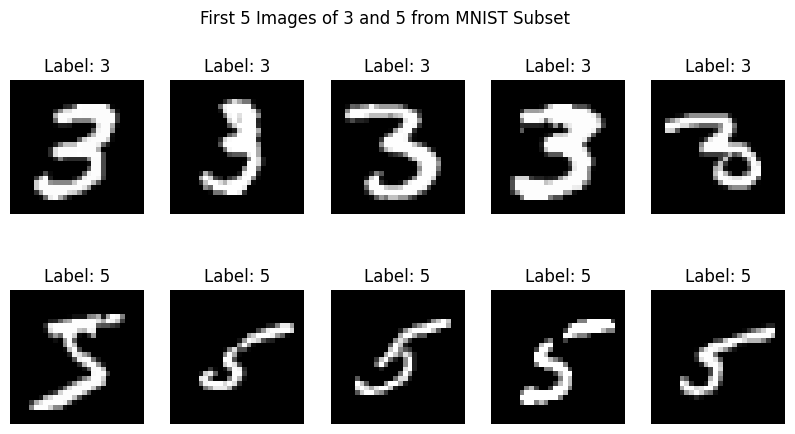

In [ ]:
# Separate images for label 3 and label 5
images_3 = X[y == 3]  # Get all images with label 3
images_5 = X[y == 5]  # Get all images with label 5

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_3 or images_5 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 3
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")
        # Plot digit 5
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()


## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100


## Step - 3 - Make a Decision function:

In [ ]:
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all


## Step - 4 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """

    # Step 3: Perceptron Learning Algorithm
    for epoch in range(1, epochs + 1):
        y_pred = decision_function(X, weights, bias)

        errors = y - y_pred

        weights += learning_rate * np.dot(errors, X)
        bias += learning_rate * np.sum(errors)

        accuracy = np.mean(y_pred == y)

        # Print every 10 epochs
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Accuracy = {accuracy:.4f}")

    return weights, bias, accuracy


## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
y_out = np.where(y == 5, 1, 0)
weights, bias, accuracy = train_perceptron(X, y_out, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)


Epoch 10: Accuracy = 0.9175
Epoch 20: Accuracy = 0.9391
Epoch 30: Accuracy = 0.9445
Epoch 40: Accuracy = 0.9482
Epoch 50: Accuracy = 0.9580
Epoch 60: Accuracy = 0.9489
Epoch 70: Accuracy = 0.9445
Epoch 80: Accuracy = 0.9511
Epoch 90: Accuracy = 0.9580
Epoch 100: Accuracy = 0.9595
The Final Accuracy is:  0.9595038307187158


## Step 5: Visualize Misclassified Images

Final Accuracy: 0.9577


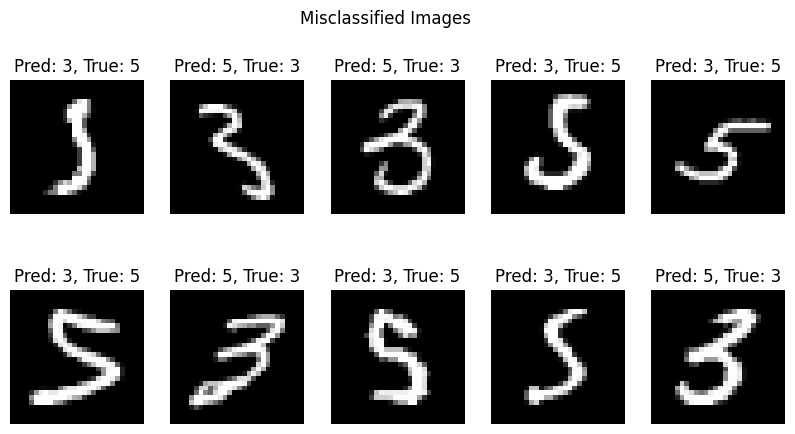

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 5, 3)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(
        axes.flat, misclassified_idx[:10]
    ):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")
